# Model Training

## 1. Import data and required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

## 2. Loading the Dataset

In [2]:
df = pd.read_csv('Souq_Ecommerce_raw_data.csv')
df.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Product_Source,Product_Category,Product_Name,Quantity_Purchased,Unit_Price,Total_Sales,Payment_Method,Year,Month,Month_Name,Weekday
0,ORD-2022-00001,9-Dec-22,C0273,P0150,"Polaroid Sunglasses for Unisex , Blue",Eyewear,"Polaroid Sunglasses for Unisex , Blue",1,250.00,250.0,COD,2022,12,December,Friday
1,ORD-2025-00002,24-Mar-25,C0212,P0569,Casio Men Black Dial Resin Band Watch aeq-110b...,Watches,Casio Men Black Dial Resin Band Watch aeq-110b...,6,313.95,1883.7,Net Banking,2025,3,March,Monday
2,ORD-2022-00003,27-Jun-22,C0666,P0009,Nike Air Zoom Pegasus 36 Running Sneakers for ...,Athletic Shoes,Nike Air Zoom Pegasus 36 Running Sneakers for ...,2,609.00,1218.0,COD,2022,6,June,Monday
3,ORD-2022-00004,21-Mar-22,C0541,P0175,"Ray Ban Sunglasses for Men - Size 55, Black Fr...",Eyewear,"Ray Ban Sunglasses for Men - Size 55, Black Fr...",1,820.00,820.0,UPI,2022,3,March,Monday
4,ORD-2022-00005,29-Jul-22,C0322,P0272,"Flamingo Rectangle Sunglasseses For Unisex,Pla...",Eyewear,"Flamingo Rectangle Sunglasseses For Unisex,Pla...",2,279.00,558.0,Debit Card,2022,7,July,Friday


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            3000 non-null   object 
 1   Order_Date          3000 non-null   object 
 2   Customer_ID         3000 non-null   object 
 3   Product_ID          3000 non-null   object 
 4   Product_Source      3000 non-null   object 
 5   Product_Category    3000 non-null   object 
 6   Product_Name        3000 non-null   object 
 7   Quantity_Purchased  3000 non-null   int64  
 8   Unit_Price          3000 non-null   float64
 9   Total_Sales         3000 non-null   float64
 10  Payment_Method      3000 non-null   object 
 11  Year                3000 non-null   int64  
 12  Month               3000 non-null   int64  
 13  Month_Name          3000 non-null   object 
 14  Weekday             3000 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 351.7

## 3. Data Cleanup

- Just making Order_Date into datetime

In [4]:
df['Order_Date'] = pd.to_datetime(df.Order_Date)
df.head()

C:\Users\chari\AppData\Local\Temp\ipykernel_20944\1008579072.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Date'] = pd.to_datetime(df.Order_Date)


,Order_ID,Order_Date,Customer_ID,Product_ID,Product_Source,Product_Category,Product_Name,Quantity_Purchased,Unit_Price,Total_Sales,Payment_Method,Year,Month,Month_Name,Weekday
0,ORD-2022-00001,2022-12-09,C0273,P0150,"Polaroid Sunglasses for Unisex , Blue",Eyewear,"Polaroid Sunglasses for Unisex , Blue",1,250.00,250.0,COD,2022,12,December,Friday
1,ORD-2025-00002,2025-03-24,C0212,P0569,Casio Men Black Dial Resin Band Watch aeq-110b...,Watches,Casio Men Black Dial Resin Band Watch aeq-110b...,6,313.95,1883.7,Net Banking,2025,3,March,Monday
2,ORD-2022-00003,2022-06-27,C0666,P0009,Nike Air Zoom Pegasus 36 Running Sneakers for ...,Athletic Shoes,Nike Air Zoom Pegasus 36 Running Sneakers for ...,2,609.00,1218.0,COD,2022,6,June,Monday
3,ORD-2022-00004,2022-03-21,C0541,P0175,"Ray Ban Sunglasses for Men - Size 55, Black Fr...",Eyewear,"Ray Ban Sunglasses for Men - Size 55, Black Fr...",1,820.00,820.0,UPI,2022,3,March,Monday
4,ORD-2022-00005,2022-07-29,C0322,P0272,"Flamingo Rectangle Sunglasseses For Unisex,Pla...",Eyewear,"Flamingo Rectangle Sunglasseses For Unisex,Pla...",2,279.00,558.0,Debit Card,2022,7,July,Friday


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Order_ID            3000 non-null   object        
 1   Order_Date          3000 non-null   datetime64[ns]
 2   Customer_ID         3000 non-null   object        
 3   Product_ID          3000 non-null   object        
 4   Product_Source      3000 non-null   object        
 5   Product_Category    3000 non-null   object        
 6   Product_Name        3000 non-null   object        
 7   Quantity_Purchased  3000 non-null   int64         
 8   Unit_Price          3000 non-null   float64       
 9   Total_Sales         3000 non-null   float64       
 10  Payment_Method      3000 non-null   object        
 11  Year                3000 non-null   int64         
 12  Month               3000 non-null   int64         
 13  Month_Name          3000 non-null   object      

## 4. Preparing X & Y variables

In [6]:
X = df.drop(columns=['Order_ID','Order_Date','Customer_ID','Product_ID','Product_Source','Year','Month','Month_Name','Weekday','Total_Sales'],axis=1)
X.head()

,Product_Category,Product_Name,Quantity_Purchased,Unit_Price,Payment_Method
0,Eyewear,"Polaroid Sunglasses for Unisex , Blue",1,250.00,COD
1,Watches,Casio Men Black Dial Resin Band Watch aeq-110b...,6,313.95,Net Banking
2,Athletic Shoes,Nike Air Zoom Pegasus 36 Running Sneakers for ...,2,609.00,COD
3,Eyewear,"Ray Ban Sunglasses for Men - Size 55, Black Fr...",1,820.00,UPI
4,Eyewear,"Flamingo Rectangle Sunglasseses For Unisex,Pla...",2,279.00,Debit Card


In [7]:
y = df['Total_Sales']
y.head()

0     250.0
1    1883.7
2    1218.0
3     820.0
4     558.0
Name: Total_Sales, dtype: float64

In [8]:
# Creating column transformer with 3 types of transformers

num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

neumeric_tansformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
[
 ("OneHotEncoder", oh_transformer, cat_features),
 ("StandardScaler",neumeric_tansformer, num_features),

]

)

In [9]:
X = preprocessor.fit_transform(X)

In [13]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((2400, 617), (600, 617))

## Creating a Evaluation Function to provide metrics after training the model

In [14]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [15]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')


Linear Regression
Model performance for Training set
- Root Mean Squared Error: 4697.5913
- Mean Absolute Error: 1072.7737
- R2 Score: 0.6347
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 2503.8906
- Mean Absolute Error: 1149.2102
- R2 Score: 0.7109


Lasso
Model performance for Training set
- Root Mean Squared Error: 4716.7851
- Mean Absolute Error: 1098.8034
- R2 Score: 0.6317
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 2350.8529
- Mean Absolute Error: 979.1890
- R2 Score: 0.7451


Ridge
Model performance for Training set
- Root Mean Squared Error: 4704.6068
- Mean Absolute Error: 1089.9378
- R2 Score: 0.6336
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 2424.7734
- Mean Absolute Error: 1084.2127
- R2 Score: 0.7289


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 2718.9852
- Mean Absolute Error: 447.1255
- 

## Results

In [16]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
7,CatBoosting Regressor,0.999270
5,Random Forest Regressor,0.992145
4,Decision Tree,0.989544
6,XGBRegressor,0.925752
8,AdaBoost Regressor,0.877346
3,K-Neighbors Regressor,0.851581
1,Lasso,0.745149
2,Ridge,0.728870
0,Linear Regression,0.710888


## Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_predict_rf = rf.predict(X_test)
print("Random Forest Accuracy Score", y_test, y_predict_rf)

Random Forest Accuracy Score 1801     195.0
1190     714.0
1817     339.0
251      909.0
2505    4746.3
         ...  
104      918.0
2087    3250.0
599      500.0
1756    1604.0
1323     850.0
Name: Total_Sales, Length: 600, dtype: float64 [1.95498800e+02 7.14140000e+02 3.39060000e+02 9.09180000e+02
 4.76568600e+03 1.69730000e+02 5.91700000e+01 1.40680000e+02
 1.80520000e+02 3.95020000e+02 2.51796000e+03 1.13040000e+02
 1.67984000e+03 5.78100000e+02 9.55350000e+02 1.98102000e+03
 1.57950000e+02 5.38480000e+02 5.45920000e+02 4.57895200e+02
 3.59800000e+02 9.65030000e+02 3.72512000e+03 1.88535000e+03
 1.34346340e+03 1.70539260e+03 2.50817532e+04 1.85746000e+03
 1.99854000e+03 1.70520000e+02 1.80256000e+03 4.82884240e+03
 7.70089600e+02 2.06553030e+03 4.19280000e+02 3.72190000e+02
 3.69958580e+03 7.49980000e+02 1.38848000e+03 2.79000000e+02
 4.15960000e+02 3.50040000e+02 8.57580000e+02 8.75900000e+02
 4.99200000e+02 2.54910000e+03 1.39000000e+02 1.70028000e+03
 1.89532000e+03 7.02551000e

In [20]:

pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_predict_rf,'Difference':y_test-y_predict_rf})
pred_df

,Actual Value,Predicted Value,Difference
1801,195.0,195.4988,-0.4988
1190,714.0,714.1400,-0.1400
1817,339.0,339.0600,-0.0600
251,909.0,909.1800,-0.1800
2505,4746.3,4765.6860,-19.3860
...,...,...,...
104,918.0,925.4200,-7.4200
2087,3250.0,3242.1200,7.8800
599,500.0,500.1000,-0.1000
1756,1604.0,1590.9600,13.0400


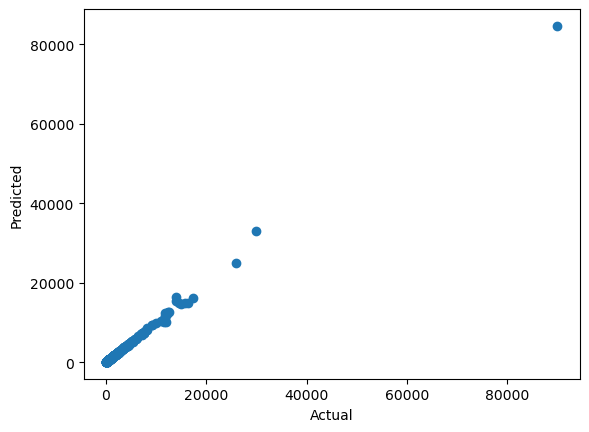

In [21]:
plt.scatter(y_test,y_predict_rf);
plt.xlabel('Actual');
plt.ylabel('Predicted');

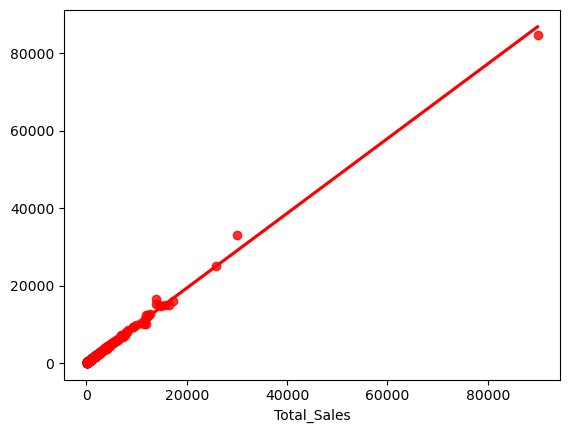

In [23]:
sns.regplot(x=y_test,y=y_predict_rf,ci=None,color ='red');